# Feature Representation Experiment: MFCC + 2D CNN

Fine-tunes an ImageNet-pretrained **ResNet18** on **MFCC** (Mel-Frequency Cepstral Coefficient) features of PSG-Audio segments for binary sleep apnea detection.

MFCC is a classical speech-feature representation that takes the log-mel spectrogram a step further: it applies a discrete cosine transform (DCT) to the log-mel coefficients, producing a more compact, decorrelated representation. The intent of this experiment is to check whether the cepstral compression helps or hurts apnea detection compared with the raw log-mel features used by the companion `mel_cnn.ipynb`.

## Objectives
- Load and preprocess PSG-Audio segments
- Perform a subject-wise stratified train/val/test split (no subject leakage; balanced apnea ratios)
- Precompute MFCC features once and stream them from disk during training
- Fine-tune a 2D CNN end-to-end for binary apnea vs non-apnea classification
- Evaluate with accuracy, macro F1, confusion matrix, and per apnea-type recall
- Persist the best checkpoint, training curves, and a results JSON

## Companion notebooks (same data, splits, loss; only the feature/backbone changes)
- [`mel_cnn.ipynb`](../Mel/mel_cnn.ipynb) — Mel spectrograms + ResNet18 (the headline backbone result)
- [`mel_pann.ipynb`](../Mel/mel_pann.ipynb) — Mel + AudioSet-pretrained PANN Cnn14
- [`mel_ast.ipynb`](../Mel/mel_ast.ipynb) — Mel + AudioSet-pretrained AST transformer (abandoned: didn't fit on the laptop GPU)
- [`raw_waveform_1dcnn.ipynb`](../Raw_waveform_1dcnn/raw_waveform_1dcnn.ipynb) — no feature engineering, small 1D CNN trained from scratch

All four notebooks use **the same stratified subject-wise split** (seed=42), so test-set metrics are directly comparable.

## Experiment summary

A high-level snapshot of the recipe — full justifications appear in the relevant sections below. Section 10 (Findings) reports headline metrics and discusses how MFCC stacks up against Mel and raw-waveform on the same task.

| Component | Choice |
|---|---|
| **Input** | 10-second 16 kHz audio segments (160,000 samples) |
| **Feature** | MFCC, **n_mfcc=40** (no delta/delta-delta), built on log-Mel with n_fft=1024, hop=512, n_mels=128, f_min=20, f_max=8000 |
| **Normalization** | None at precompute time (raw float16); model's `BatchNorm2d(1)` learns dataset-level scaling at training time |
| **Precomputation** | Computed once on GPU via torchaudio, saved to disk as float16 (~2-3 GB cache) |
| **Backbone** | ResNet18, ImageNet-pretrained; conv1 adapted from 3-channel to 1-channel by averaging |
| **Input adapter** | `BatchNorm2d(1)` before the encoder — adapts MFCC scale to ImageNet-trained distribution |
| **Classifier head** | `Dropout(0.6)` + `Linear(512, 2)` |
| **Loss** | Focal loss (γ=2.0) with class-weighted α |
| **Optimizer** | AdamW, LR=1e-4, weight decay=1e-3 |
| **Scheduler** | `ReduceLROnPlateau` on val macro-F1, patience=2, factor=0.5 |
| **Augmentation** | SpecAugment-style on GPU (2 masks per batch, freq=8 of 40, time=40 frames) |
| **Mixed precision** | bf16 autocast on GPU (Tensor Cores); fp32 fallback on CPU |
| **Regularization** | Dropout 0.6 in head, gradient clipping (max norm 1.0) |
| **Subject-wise split** | Stratified by per-subject apnea fraction (quartiles); 70/15/15, seed=42 — *identical test set across all backbone notebooks* |
| **Schedule** | Up to 15 epochs, early stop after 5 stagnant epochs on val macro-F1 |
| **Selection** | Best-by-val-F1 checkpoint reloaded for test evaluation |

## 1. Setup

Imports, device selection, and reproducibility seeds.

In [15]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import torchaudio

# Shared dataset class (importable so DataLoader workers can pickle it on Windows)
from audio_datasets import MFCCDataset

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Configuration

Paths, audio/feature parameters, and training hyperparameters. All knobs you'd want to change between runs live in the next cell.

In [17]:
# === Dataset ===
DATASET_ROOT = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset")
PSG_DIR      = DATASET_ROOT / "PSG-AUDIO" / "APNEA_EDF"
AP_TYPES_DIR = DATASET_ROOT / "APNEA_types"

# === Precomputed features ===
PRECOMPUTED_DIR = DATASET_ROOT / "PSG-AUDIO" / "PRECOMPUTED" / "mfcc_v1"

# === Artifact output ===
# Notebook lives at experiments/notebooks/audio/feature_representation/MFCC/,
# so parents[4] climbs back to the project root.
PROJECT_ROOT   = Path.cwd().resolve().parents[4]
ARTIFACT_DIR   = PROJECT_ROOT / "experiments" / "artifacts" / "audio" / "feature_representation" / "mfcc_cnn"
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
RESULTS_DIR    = ARTIFACT_DIR / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# === Audio ===
SAMPLE_RATE = 16000

# === Apnea type mapping ===
APNEA_TYPE_NAMES = {0: "non-apnea", 1: "OSA", 2: "CSA", 3: "Mixed/Hypopnea", 4: "Other"}

# === MFCC params (used at precompute time) ===
# MFCC pipeline: STFT -> Mel filterbank -> log -> DCT -> first n_mfcc coefficients.
# n_mfcc=40 is a standard choice; common in speech recognition. The mel front-end
# uses the same bands/range as mel_cnn.ipynb so the features are comparable.
N_MFCC          = 40
N_FFT           = 1024
HOP_LENGTH      = 512
N_MELS          = 128
F_MIN           = 20
F_MAX           = 8000
PRECOMPUTE_BATCH = 64

# === SpecAugment-style augmentation (training only, applied on GPU per batch) ===
# Same time/freq mask pattern as mel_cnn but FREQ_MASK_PARAM scaled to n_mfcc=40.
FREQ_MASK_PARAM = 8
TIME_MASK_PARAM = 40
N_SPEC_MASKS    = 2

# === DataLoader ===
BATCH_SIZE   = 128
NUM_WORKERS  = 4
MFCC_CACHE_SIZE = 16

# === Loss ===
FOCAL_GAMMA = 2.0

# === Training ===
SEED                 = 42
NUM_EPOCHS           = 15
LEARNING_RATE        = 1e-4
WEIGHT_DECAY         = 1e-3
DROPOUT              = 0.6
GRAD_CLIP            = 1.0
EARLY_STOP_PATIENCE  = 5
LR_SCHED_PATIENCE    = 2
NUM_CLASSES          = 2
CLASS_NAMES          = ["non-apnea", "apnea"]

# === Reproducibility ===
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

print("Artifact dir:", ARTIFACT_DIR)
print("Precomputed dir:", PRECOMPUTED_DIR)
print("PSG dir exists:", PSG_DIR.exists())

Artifact dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\mfcc_cnn
Precomputed dir: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset\PSG-AUDIO\PRECOMPUTED\mfcc_v1
PSG dir exists: True


## 3. Data preparation

### 3.1 Build records DataFrame

Builds a flat DataFrame where each row is one audio segment with columns:
- `subject_id` — patient ID
- `segment_idx` — index within the subject's npy array
- `label` — 0 = non-apnea, 1 = apnea
- `apnea_type` — 0 for non-apnea; 1/2/3/4 for apnea type
- `file_type` — `ap` or `nap`

Audio payloads are not loaded here — only npy headers are read via `mmap_mode='r'`.

In [18]:
def build_records(psg_dir, ap_types_dir):
    """Build (subject_id, segment_idx, label, apnea_type, file_type) records
    from npy headers without loading audio payloads.

    Subjects with no nap.npy contribute apnea segments only — handled via the
    file-existence check below, so no hardcoded subject list is needed.
    """
    records = []
    subjects = sorted(os.listdir(psg_dir))

    for subj in subjects:
        subj_path  = psg_dir / subj
        ap_file    = subj_path / f"{subj}_ap.npy"
        nap_file   = subj_path / f"{subj}_nap.npy"
        types_file = ap_types_dir / f"{subj}_ap_types.npy"

        if ap_file.exists():
            ap_types = np.load(types_file, allow_pickle=False) if types_file.exists() else None
            ap_mm = np.load(ap_file, mmap_mode="r")
            n_ap = ap_mm.shape[0]
            del ap_mm
            for i in range(n_ap):
                records.append({
                    "subject_id": subj, "segment_idx": i, "label": 1,
                    "apnea_type": int(ap_types[i]) if ap_types is not None else -1,
                    "file_type": "ap",
                })

        if not nap_file.exists():
            continue
        nap_mm = np.load(nap_file, mmap_mode="r")
        n_nap = nap_mm.shape[0]
        del nap_mm
        for i in range(n_nap):
            records.append({
                "subject_id": subj, "segment_idx": i, "label": 0,
                "apnea_type": 0, "file_type": "nap",
            })

    return pd.DataFrame(records)


df = build_records(PSG_DIR, AP_TYPES_DIR)
print("Total records:", len(df))
print(df["label"].value_counts())
df.head()

Total records: 103210
label
1    64585
0    38625
Name: count, dtype: int64


,subject_id,segment_idx,label,apnea_type,file_type
0,00000995-100507,0,1,1,ap
1,00000995-100507,1,1,1,ap
2,00000995-100507,2,1,1,ap
3,00000995-100507,3,1,1,ap
4,00000995-100507,4,1,1,ap


### 3.2 Subject-wise stratified split

**Why subject-wise**: each subject's audio is highly correlated across their own segments (same microphone placement, same voice, same ambient noise). Splitting segments randomly would leak subject-specific cues into validation/test, producing optimistic metrics that don't generalize to unseen patients.

**Why stratified by apnea fraction**: subjects vary widely in how many apnea vs non-apnea segments they contributed (some have 600 apnea / 70 non-apnea, others closer to 1:1). A pure random subject split therefore drifts the apnea ratio across the three splits. Bucketing subjects into quartiles by per-subject apnea fraction and splitting *within* each quartile keeps the apnea ratio stable across train/val/test (within ~1 pp of the dataset-wide 62.6%).

**Same recipe + `random_state=42`** as the other backbone notebooks → **the test set is identical**. Direct apples-to-apples comparison of MFCC vs Mel vs raw-waveform features is therefore meaningful.

In [19]:
def create_subjectwise_splits(df, subject_col="subject_id", train_size=0.70, val_size=0.15, test_size=0.15, random_state=42, n_strata=4):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-8

    per_subj = (
        df.groupby(subject_col)["label"]
          .agg(["sum", "count"])
          .rename(columns={"sum": "n_apnea", "count": "n_total"})
    )
    per_subj["ap_frac"] = per_subj["n_apnea"] / per_subj["n_total"]
    per_subj["stratum"] = pd.qcut(per_subj["ap_frac"], q=n_strata, labels=False, duplicates="drop")

    train_subj, val_subj, test_subj = [], [], []
    val_ratio_of_temp = val_size / (val_size + test_size)

    for stratum, group in per_subj.groupby("stratum"):
        subjects = sorted(group.index.tolist())
        if len(subjects) < 3:
            train_subj.extend(subjects)
            continue
        tr, temp = train_test_split(subjects, test_size=(1 - train_size), random_state=random_state, shuffle=True)
        if len(temp) < 2:
            train_subj.extend(tr); val_subj.extend(temp); continue
        va, te = train_test_split(temp, test_size=(1 - val_ratio_of_temp), random_state=random_state, shuffle=True)
        train_subj.extend(tr); val_subj.extend(va); test_subj.extend(te)

    train_df = df[df[subject_col].isin(train_subj)].reset_index(drop=True)
    val_df   = df[df[subject_col].isin(val_subj)].reset_index(drop=True)
    test_df  = df[df[subject_col].isin(test_subj)].reset_index(drop=True)

    return train_df, val_df, test_df, train_subj, val_subj, test_subj


train_df, val_df, test_df, train_subjects, val_subjects, test_subjects = create_subjectwise_splits(df)

print(f"Train: {len(set(train_df['subject_id']))} subj, {len(train_df)} samples ({(train_df['label']==1).mean():.1%} apnea)")
print(f"Val  : {len(set(val_df['subject_id']))} subj, {len(val_df)} samples ({(val_df['label']==1).mean():.1%} apnea)")
print(f"Test : {len(set(test_df['subject_id']))} subj, {len(test_df)} samples ({(test_df['label']==1).mean():.1%} apnea)")

with open(RESULTS_DIR / "split_subjects.json", "w") as f:
    json.dump({
        "train_subjects": sorted(train_subjects),
        "val_subjects":   sorted(val_subjects),
        "test_subjects":  sorted(test_subjects),
    }, f, indent=2)

Train: 133 subj, 70430 samples (61.9% apnea)
Val  : 29 subj, 14822 samples (62.1% apnea)
Test : 30 subj, 17958 samples (65.8% apnea)


### 3.3 Class weights for focal loss

Weights are computed from the **training split only** so that no test/val statistics leak into training. The values are used as the `α` term in focal loss (Section 7.1) — they handle class imbalance, while the focal `(1 − pₜ)^γ` factor handles hard-example focusing.

In [20]:
def compute_class_weights(train_df, label_col="label", num_classes=2):
    counts = train_df[label_col].value_counts().sort_index()
    total  = len(train_df)
    weights = torch.tensor([total / (num_classes * counts[c]) for c in range(num_classes)], dtype=torch.float32)
    print("Class counts (train):", counts.to_dict())
    print("Class weights:", weights.tolist())
    return weights


class_weights = compute_class_weights(train_df)

Class counts (train): {0: 26858, 1: 43572}
Class weights: [1.3111549615859985, 0.8082025051116943]


## 4. Feature precomputation

Computes MFCC features for all segments using **torchaudio on GPU** and saves to disk as float16 `.npy` files. This runs once — subsequent runs skip subjects whose precomputed files already exist. Training then loads precomputed tensors instead of recomputing the feature on every sample every epoch.

**No normalization at precompute time.** Raw MFCC values are stored — the model's input `BatchNorm2d` (Section 6) learns dataset-level mean/std at training time. A common alternative (per-sample mean/std normalization, which the original notebook used) destroys cross-segment loudness, which the EDA flagged as discriminative for apnea vs non-apnea.

In [21]:
PRECOMPUTED_DIR.mkdir(parents=True, exist_ok=True)

mfcc_transform = torchaudio.transforms.MFCC(
    sample_rate=SAMPLE_RATE,
    n_mfcc=N_MFCC,
    melkwargs={
        "n_fft": N_FFT,
        "hop_length": HOP_LENGTH,
        "n_mels": N_MELS,
        "f_min": F_MIN,
        "f_max": F_MAX,
    },
).to(device)

subjects = sorted(os.listdir(PSG_DIR))
skipped, computed = 0, 0

for subj_idx, subj in enumerate(subjects):
    subj_path = PSG_DIR / subj

    for file_type in ['ap', 'nap']:
        src = subj_path / f'{subj}_{file_type}.npy'
        dst = PRECOMPUTED_DIR / subj / f'{subj}_{file_type}_mfcc.npy'

        if dst.exists():
            skipped += 1
            continue
        if not src.exists():
            continue

        data = np.load(src, allow_pickle=False).astype(np.float32)
        all_mfccs = []

        for i in range(0, len(data), PRECOMPUTE_BATCH):
            batch = torch.from_numpy(data[i:i+PRECOMPUTE_BATCH]).to(device, non_blocking=True)
            with torch.no_grad():
                mfcc = mfcc_transform(batch)   # (B, n_mfcc, time)
            all_mfccs.append(mfcc.cpu().half().numpy())

        result = np.concatenate(all_mfccs, axis=0)
        dst.parent.mkdir(parents=True, exist_ok=True)
        np.save(dst, result)
        computed += 1

    if (subj_idx + 1) % 20 == 0:
        print(f'  {subj_idx+1}/{len(subjects)} subjects processed...')

print(f'Done! Computed: {computed} files | Skipped (already exist): {skipped}')
print(f'Saved to: {PRECOMPUTED_DIR}')

  20/192 subjects processed...
  40/192 subjects processed...
  60/192 subjects processed...
  80/192 subjects processed...
  100/192 subjects processed...
  120/192 subjects processed...
  140/192 subjects processed...
  160/192 subjects processed...
  180/192 subjects processed...
Done! Computed: 0 files | Skipped (already exist): 383
Saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\Audio Dataset\PSG-AUDIO\PRECOMPUTED\mfcc_v1


## 5. Datasets and DataLoaders

The `MFCCDataset` class lives in `audio_datasets.py` (imported in Section 1). Defining it in a `.py` file is what allows PyTorch DataLoader workers to pickle the class on Windows + Jupyter — classes defined directly in notebook cells cannot be spawned across worker processes.

In [22]:
train_dataset = MFCCDataset(train_df, PRECOMPUTED_DIR, max_cache=MFCC_CACHE_SIZE)
val_dataset   = MFCCDataset(val_df,   PRECOMPUTED_DIR, max_cache=MFCC_CACHE_SIZE)
test_dataset  = MFCCDataset(test_df,  PRECOMPUTED_DIR, max_cache=MFCC_CACHE_SIZE)

pin = torch.cuda.is_available()
persist = NUM_WORKERS > 0
g = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=pin,
    persistent_workers=persist, generator=g,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=pin, persistent_workers=persist,
)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 70430 | Val: 14822 | Test: 17958


Batch MFCC shape: torch.Size([128, 1, 40, 313])
Batch MFCC range: [-1131.00, 180.88]
Batch labels: [1, 1, 1, 0, 1, 1, 1, 0, 1, 1]


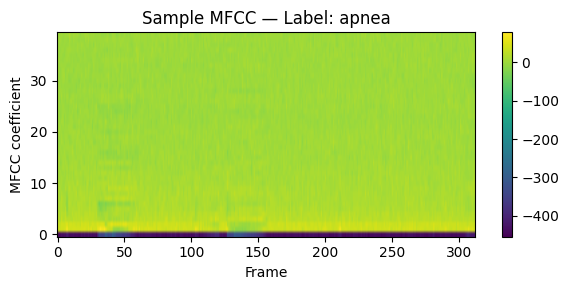

In [23]:
# Sanity check — inspect one batch
feats, labels = next(iter(train_loader))
print("Batch MFCC shape:", feats.shape)
print("Batch MFCC range:", f"[{feats.min().item():.2f}, {feats.max().item():.2f}]")
print("Batch labels:", labels[:10].tolist())

plt.figure(figsize=(6, 3))
plt.imshow(feats[0].squeeze().numpy(), aspect="auto", origin="lower")
plt.title(f"Sample MFCC \u2014 Label: {CLASS_NAMES[labels[0]]}")
plt.ylabel("MFCC coefficient")
plt.xlabel("Frame")
plt.colorbar()
plt.tight_layout()
plt.show()

## 6. Model

ResNet18 adapted for single-channel MFCC input. Same architecture pattern as `mel_cnn.ipynb` — only the input feature differs.

**Backbone — ImageNet-pretrained ResNet18.** The first convolution is reinitialized from 3-channel to 1-channel by **averaging the pretrained kernel across the input-channel dimension**. This is a standard transfer-learning trick that preserves the spatial filter shapes the network learned on natural images, just on a single-channel input.

**Input adapter — `BatchNorm2d(1)` before the encoder.** Raw MFCC values are unbounded and not normalized at precompute time. BatchNorm learns dataset-level mean/std from training data and rescales accordingly — gives the pretrained early layers a more familiar input distribution without the destructive per-sample normalization the original notebook used.

**Classifier head — `Dropout(0.6) + Linear(512, num_classes)`** after ResNet18's adaptive avg-pool. Same heavy dropout setting that worked well for the Mel-feature variant.

In [24]:
class MFCCCNNClassifier(nn.Module):
    """ResNet18 adapted for single-channel MFCC input.

    Uses ImageNet-pretrained weights; conv1 is re-initialized by averaging
    the pretrained 3-channel kernel across the channel dim.

    A BatchNorm2d at the input adapts the raw MFCC scale to a distribution
    closer to what ResNet's pretrained early layers expect, without baking
    in any per-segment hack.
    """
    def __init__(self, num_classes=2, dropout=0.6, pretrained=True):
        super().__init__()

        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        base = models.resnet18(weights=weights)

        # Adapt first conv from 3-channel to 1-channel by averaging pretrained weights
        original_conv1 = base.conv1
        new_conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained:
            with torch.no_grad():
                new_conv1.weight.copy_(original_conv1.weight.mean(dim=1, keepdim=True))
        base.conv1 = new_conv1

        self.input_norm = nn.BatchNorm2d(1)
        self.encoder = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
            base.avgpool,
            nn.Flatten(),
        )
        self.feature_dim = 512

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.feature_dim, num_classes),
        )

    def forward(self, x):
        x = self.input_norm(x)
        features = self.encoder(x)
        return self.classifier(features)


model = MFCCCNNClassifier(num_classes=NUM_CLASSES, dropout=DROPOUT, pretrained=True).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: MFCCCNNClassifier | trainable params: {n_params:,} | feature dim: {model.feature_dim}")

Model: MFCCCNNClassifier | trainable params: 11,171,268 | feature dim: 512


## 7. Training

### 7.1 Loss, optimizer, scheduler, and augmentation

**Loss — Focal loss (γ=2.0) with class-weighted α.** `FL(pₜ) = −α · (1 − pₜ)^γ · log(pₜ)`. The α term handles the ~62% / 38% class imbalance, while `(1 − pₜ)^γ` down-weights confident-correct predictions so each gradient step refocuses on harder examples.

**Optimizer — AdamW**, LR=1e-4, weight decay=1e-3. Decoupled weight decay (correct L2 regularization, unlike plain Adam + `weight_decay`).

**Scheduler — `ReduceLROnPlateau`** keyed on **val macro-F1** (`mode='max'`). Halves the LR when val plateaus for `LR_SCHED_PATIENCE=2` epochs.

**Augmentation — SpecAugment-style** applied **batch-wise on GPU** during training only: 2 masks per batch, frequency mask up to 8 of 40 MFCC coefficients, time mask up to 40 of ~313 frames.

In [25]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class alpha weights.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        if alpha is not None:
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, logits, targets):
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()
        focal_weight = (1.0 - pt) ** self.gamma
        loss = -focal_weight * log_pt
        if self.alpha is not None:
            loss = self.alpha[targets] * loss
        return loss.mean()


criterion = FocalLoss(alpha=class_weights.to(device), gamma=FOCAL_GAMMA).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=LR_SCHED_PATIENCE)

# GPU-side SpecAugment-style masking — applied per-batch in train_one_epoch only.
freq_mask_gpu = torchaudio.transforms.FrequencyMasking(freq_mask_param=FREQ_MASK_PARAM).to(device)
time_mask_gpu = torchaudio.transforms.TimeMasking(time_mask_param=TIME_MASK_PARAM).to(device)

def spec_augment_batch(x):
    for _ in range(N_SPEC_MASKS):
        x = freq_mask_gpu(x)
        x = time_mask_gpu(x)
    return x

print(f"Loss: FocalLoss(gamma={FOCAL_GAMMA}, alpha={class_weights.tolist()})")
print(f"Optimizer: AdamW | LR: {LEARNING_RATE} | WD: {WEIGHT_DECAY}")

Loss: FocalLoss(gamma=2.0, alpha=[1.3111549615859985, 0.8082025051116943])
Optimizer: AdamW | LR: 0.0001 | WD: 0.001


### 7.2 Train and validate utilities

bf16 autocast on GPU (Tensor Cores). Falls back to fp32 on CPU automatically.

In [26]:
_AMP_DTYPE = torch.bfloat16
_USE_AMP = torch.cuda.is_available()


def _epoch_metrics(loss_sum, n_samples, preds, labels):
    avg_loss = (loss_sum / n_samples).item()
    preds_np  = preds.cpu().numpy()
    labels_np = labels.cpu().numpy()
    acc      = (preds_np == labels_np).mean()
    macro_f1 = f1_score(labels_np, preds_np, average='macro')
    return avg_loss, acc, macro_f1


def train_one_epoch(model, loader, criterion, optimizer, device, augment_fn=None, grad_clip=None):
    model.train()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if augment_fn is not None:
            inputs = augment_fn(inputs)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=_AMP_DTYPE, enabled=_USE_AMP):
            logits = model(inputs)
            loss   = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        bs = inputs.size(0)
        loss_sum += loss.detach().float() * bs
        n_samples += bs
        all_preds.append(torch.argmax(logits.detach(), dim=1))
        all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum = torch.zeros(1, device=device)
    n_samples = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with torch.autocast(device_type='cuda', dtype=_AMP_DTYPE, enabled=_USE_AMP):
                logits = model(inputs)
                loss   = criterion(logits, labels)
            bs = inputs.size(0)
            loss_sum += loss.float() * bs
            n_samples += bs
            all_preds.append(torch.argmax(logits, dim=1))
            all_labels.append(labels)

    return _epoch_metrics(loss_sum, n_samples, torch.cat(all_preds), torch.cat(all_labels))

### 7.3 Checkpoint helper

In [27]:
def save_checkpoint(path, model, optimizer, epoch, best_val_acc, best_val_f1):
    torch.save({
        "epoch"               : epoch,
        "model_state_dict"    : model.state_dict(),
        "encoder_state_dict"  : model.encoder.state_dict(),
        "classifier_state_dict": model.classifier.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_acc"        : best_val_acc,
        "best_val_macro_f1"   : best_val_f1,
        "feature_dim"         : model.feature_dim,
        "num_classes"         : NUM_CLASSES,
    }, path)


BEST_CHECKPOINT_PATH = CHECKPOINT_DIR / "best_mfcc_cnn.pth"

### 7.4 Training loop

Trains for up to `NUM_EPOCHS` with early stopping on val macro-F1. The best checkpoint (highest val F1) is saved to disk and reloaded for evaluation in Section 8.

In [28]:
history = {'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
           'val_loss': [],   'val_acc': [],   'val_macro_f1': []}

best_val_f1 = -1.0
best_val_acc = -1.0
best_epoch = -1
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch [{epoch + 1}/{NUM_EPOCHS}]')
    print('-' * 50)

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        augment_fn=spec_augment_batch, grad_clip=GRAD_CLIP,
    )
    val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc); history['train_macro_f1'].append(train_f1)
    history['val_loss'].append(val_loss);     history['val_acc'].append(val_acc);     history['val_macro_f1'].append(val_f1)

    print(f'Train \u2014 Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
    print(f'Val   \u2014 Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_val_acc = val_acc
        best_epoch = epoch + 1
        save_checkpoint(BEST_CHECKPOINT_PATH, model, optimizer, epoch, best_val_acc, best_val_f1)
        print(f'  \u2713 New best saved (Val F1: {best_val_f1:.4f})')
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f'  No improvement for {epochs_no_improve} epoch(s)')
        if epochs_no_improve >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping triggered after {epoch + 1} epochs.')
            break

actual_epochs = len(history['train_loss'])
print(f'\nBest epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f} | Best Val Acc: {best_val_acc:.4f}')


Epoch [1/15]
--------------------------------------------------
Train — Loss: 0.2049 | Acc: 0.6095 | F1: 0.5997
Val   — Loss: 0.1663 | Acc: 0.5947 | F1: 0.5832
  ✓ New best saved (Val F1: 0.5832)

Epoch [2/15]
--------------------------------------------------
Train — Loss: 0.1506 | Acc: 0.7126 | F1: 0.7026
Val   — Loss: 0.1695 | Acc: 0.7452 | F1: 0.7350
  ✓ New best saved (Val F1: 0.7350)

Epoch [3/15]
--------------------------------------------------
Train — Loss: 0.1348 | Acc: 0.7495 | F1: 0.7398
Val   — Loss: 0.1835 | Acc: 0.7748 | F1: 0.7576
  ✓ New best saved (Val F1: 0.7576)

Epoch [4/15]
--------------------------------------------------
Train — Loss: 0.1252 | Acc: 0.7673 | F1: 0.7582
Val   — Loss: 0.2059 | Acc: 0.4493 | F1: 0.4033
  No improvement for 1 epoch(s)

Epoch [5/15]
--------------------------------------------------
Train — Loss: 0.1191 | Acc: 0.7808 | F1: 0.7720
Val   — Loss: 0.3452 | Acc: 0.4263 | F1: 0.3598
  No improvement for 2 epoch(s)

Epoch [6/15]
---------

### 7.5 Training curves

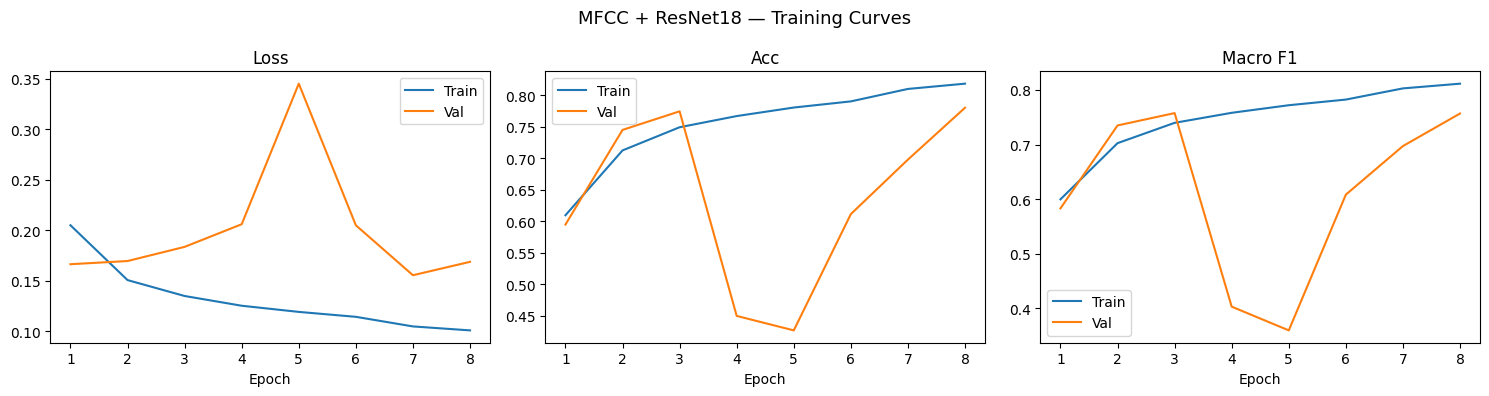

In [29]:
epochs = range(1, actual_epochs + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ['loss', 'acc', 'macro_f1']):
    ax.plot(epochs, history[f'train_{metric}'], label='Train')
    ax.plot(epochs, history[f'val_{metric}'],   label='Val')
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Epoch')
    ax.legend()
plt.suptitle('MFCC + ResNet18 \u2014 Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Evaluation

### 8.1 Overall test metrics and confusion matrix

Loads the best-by-val-F1 checkpoint and reports:
- **Loss (focal)** — matches the training objective
- **Loss (unweighted CE)** — the standard cross-entropy form, easier to interpret without knowing the focal-loss α weights
- **Accuracy** — overall fraction correct
- **Macro F1** — unweighted average of per-class F1 (treats apnea and non-apnea equally regardless of frequency)

The confusion matrix shows which class confusions dominate the errors.

In [30]:
ckpt = torch.load(BEST_CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

test_loss, test_acc, test_f1 = validate_one_epoch(model, test_loader, criterion, device)
test_loss_unweighted, _, _ = validate_one_epoch(model, test_loader, nn.CrossEntropyLoss(), device)

print('=== Test Results ===')
print(f'Loss (focal, training objective): {test_loss:.4f}')
print(f'Loss (unweighted CE)            : {test_loss_unweighted:.4f}')
print(f'Accuracy                        : {test_acc:.4f}')
print(f'Macro F1                        : {test_f1:.4f}')

=== Test Results ===
Loss (focal, training objective): 0.2260
Loss (unweighted CE)            : 0.5810
Accuracy                        : 0.7491
Macro F1                        : 0.7127


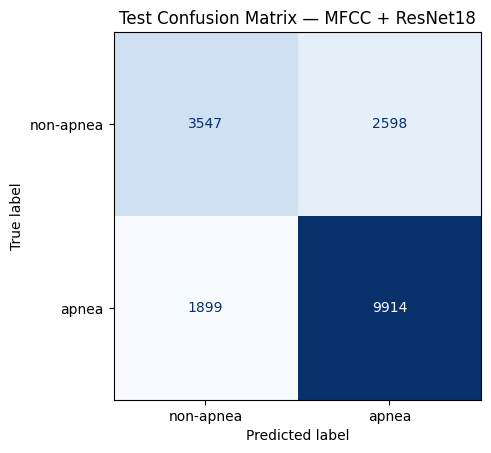

              precision    recall  f1-score   support

   non-apnea       0.65      0.58      0.61      6145
       apnea       0.79      0.84      0.82     11813

    accuracy                           0.75     17958
   macro avg       0.72      0.71      0.71     17958
weighted avg       0.74      0.75      0.75     17958



In [31]:
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        preds = torch.argmax(model(inputs.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Test Confusion Matrix \u2014 MFCC + ResNet18")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

### 8.2 Per apnea-type recall

Evaluates only on apnea segments, broken down by clinical type (OSA / CSA / Mixed-Hypopnea / Other). Useful for spotting which apnea patterns the model handles well versus which it under-detects.

In [32]:
ap_test_df = test_df[test_df['label'] == 1].copy()
ap_dataset = MFCCDataset(ap_test_df, PRECOMPUTED_DIR)
ap_loader  = DataLoader(ap_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

preds_all, types_all = [], ap_test_df['apnea_type'].tolist()
with torch.no_grad():
    for inputs, _ in ap_loader:
        preds = torch.argmax(model(inputs.to(device)), dim=1)
        preds_all.extend(preds.cpu().numpy())

print('=== Per Apnea-Type Recall (correctly detected as apnea) ===')
for t, name in APNEA_TYPE_NAMES.items():
    if t == 0:
        continue
    idxs = [i for i, tp in enumerate(types_all) if tp == t]
    if not idxs:
        continue
    correct = sum(preds_all[i] == 1 for i in idxs)
    print(f'  Type {t} ({name}): {correct}/{len(idxs)} = {correct/len(idxs):.3f}')

=== Per Apnea-Type Recall (correctly detected as apnea) ===
  Type 1 (OSA): 1041/1861 = 0.559
  Type 2 (CSA): 1917/2021 = 0.949
  Type 3 (Mixed/Hypopnea): 6690/7649 = 0.875
  Type 4 (Other): 266/282 = 0.943


## 9. Save results

In [33]:
results = {
    'experiment'      : 'mfcc_cnn',
    'feature'         : 'mfcc',
    'model'           : 'ResNet18 (ImageNet-pretrained)',
    'best_epoch'      : best_epoch,
    'best_val_acc'    : float(best_val_acc),
    'best_val_macro_f1': float(best_val_f1),
    'test_loss'       : float(test_loss),
    'test_loss_unweighted': float(test_loss_unweighted),
    'test_accuracy'   : float(test_acc),
    'test_macro_f1'   : float(test_f1),
    'classification_report': report,
    'config': {
        'sample_rate'  : SAMPLE_RATE,
        'n_mfcc'       : N_MFCC,
        'n_fft'        : N_FFT,
        'hop_length'   : HOP_LENGTH,
        'n_mels'       : N_MELS,
        'f_min'        : F_MIN,
        'f_max'        : F_MAX,
        'batch_size'   : BATCH_SIZE,
        'num_epochs'   : NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'weight_decay' : WEIGHT_DECAY,
        'dropout'      : DROPOUT,
        'loss'         : {'type': 'focal', 'gamma': FOCAL_GAMMA, 'alpha': class_weights.tolist()},
        'spec_aug'     : {'freq': FREQ_MASK_PARAM, 'time': TIME_MASK_PARAM, 'n_masks': N_SPEC_MASKS},
        'num_train'    : len(train_dataset),
        'num_val'      : len(val_dataset),
        'num_test'     : len(test_dataset),
    }
}

with open(RESULTS_DIR / 'mfcc_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=2)
with open(RESULTS_DIR / 'train_history.json', 'w') as f:
    json.dump(history, f, indent=2)

print('Results saved to:', RESULTS_DIR)

Results saved to: C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\ApneaSense\experiments\artifacts\audio\feature_representation\mfcc_cnn\results


## 10. Findings

### Headline metrics

| Metric | Value |
|---|---|
| Test accuracy | **0.7491** |
| Test macro F1 | **0.7127** |
| Test loss (unweighted CE) | 0.5810 |
| Test loss (focal, training objective) | 0.2260 |
| Best val macro F1 | 0.7576 (epoch 3 of 8) |
| Best val accuracy | 0.7748 |
| Trainable parameters | 11,171,268 |

### Per apnea-type recall (test set, apnea segments only)

| Apnea sub-type | Recall | Test segments |
|---|---|---|
| Type 1 — OSA (Obstructive Sleep Apnea) | **0.559** | 1,861 |
| Type 2 — CSA (Central Sleep Apnea) | **0.949** | 2,021 |
| Type 3 — Mixed / Hypopnea | **0.875** | 7,649 |
| Type 4 — Other | **0.943** | 282 |

### Cross-feature comparison (same data, splits, focal loss; only the input feature changes)

Because all backbone notebooks share the same stratified split (`random_state=42`), test-set numbers are directly comparable.

| Notebook | Feature | Backbone | Pretraining | Test F1 | Test Acc | OSA recall |
|---|---|---|---|---|---|---|
| [`mel_cnn.ipynb`](../Mel/mel_cnn.ipynb) | Log-Mel (n_mels=128) | ResNet18 | ImageNet | **0.7766** | **0.8038** | **0.686** |
| [`mel_pann.ipynb`](../Mel/mel_pann.ipynb) | Log-Mel (PANN internal, n_mels=64) | PANN Cnn14 | AudioSet | 0.7535 | 0.7693 | 0.567 |
| **`mfcc_cnn.ipynb` (this)** | **MFCC (n_mfcc=40)** | **ResNet18** | **ImageNet** | 0.7127 | 0.7491 | 0.559 |
| [`raw_waveform_1dcnn.ipynb`](../Raw_waveform_1dcnn/raw_waveform_1dcnn.ipynb) | Raw waveform | 1D CNN | none | 0.6288 | 0.6662 | 0.531 |

MFCC sits cleanly **between raw waveform and Mel** on overall F1: it beats from-scratch raw-waveform learning (+8 pp F1) but underperforms the same-backbone Mel variant (-6 pp F1). This is the textbook story of feature engineering — MFCC's DCT compression *helps* a weak baseline by injecting domain knowledge, but *costs* a strong baseline by discarding spectral detail.

### Per-class observations — where MFCC wins vs loses

| Sub-type | MFCC | mel_cnn | Δ | What's happening |
|---|---|---|---|---|
| OSA | 0.559 | 0.686 | **−13 pp** | DCT smooths away the fine high-frequency spectral structure that distinguishes restricted-airflow snoring from normal breathing |
| CSA | **0.949** | 0.937 | +1 pp | "Patient stops breathing" → silence — the spectral envelope shift is dramatic enough that even 40 cepstral coefficients capture it |
| Mixed/Hypopnea | 0.875 | 0.906 | −3 pp | Modest loss; the partial-airway-collapse pattern is in between OSA's subtlety and CSA's obviousness |
| Other | **0.943** | 0.876 | **+7 pp** | Surprising win — the Other category lumps several distinctive patterns; MFCC's compression seems to act as a useful regularizer here |

The OSA gap is the most informative finding: **MFCC's DCT step is exactly the wrong compression for OSA detection.** OSA cues live in fine spectral structure (snoring formants, restricted-airflow whistling) that the DCT decorrelation step smooths into the discarded higher-order coefficients.

### Training behavior — fast but unstable

The run completed in **8 epochs** (vs mel_cnn's 12) — partly because of MFCC's smaller feature volume (40 × 313 = 12.5k cells per sample vs Mel's 128 × 313 = 40k), partly because val F1 stopped improving early. The val curve was notably unstable:

- E1: 0.583 (initial best)
- E2: 0.735 ✓ new best
- E3: 0.758 ✓ **best overall**
- E4: **0.403** (crash)
- E5: **0.360** (deeper crash)
- E6: 0.608 (partial recovery)
- E7: 0.697 (recovery continues)
- E8: 0.757 (back to ~best, but not beating epoch 3) → early stop fires

Train F1 climbed monotonically (0.60 → 0.81), so the crashes weren't an optimization breakdown — they were val-set sensitivity. Likely cause: **MFCC features have a much narrower dynamic range than Mel, and small distribution shifts between train and val batches (combined with BatchNorm running-stats updates) produce large logit changes**. mel_cnn's broader feature distribution provides more cushion.

### Discussion

**MFCC underperforms Mel on this task — but the gap isn't huge.** The DCT-and-truncate step costs 6 percentage points of F1 vs raw log-Mel features (0.7127 vs 0.7766). For a feature representation designed in the 1980s for HMM-based speech recognition with 100-1000× less compute, MFCC holds up surprisingly well against a modern CNN.

**MFCC is genuinely a feature *and* a regularizer.** It strictly loses information vs the underlying log-Mel (DCT is invertible, but truncating to 40 coefficients is not), so any case where MFCC *beats* Mel on a sub-class (CSA +1 pp, Other +7 pp) is a regularization effect — the compression filtered out noise that was confusing the Mel-based classifier on those classes.

**But for the headline task — mixed apnea detection with OSA in the mix — Mel wins.** OSA's specific spectral cues are too narrow-band for DCT compression to preserve.

**Why was MFCC fast?** Three reasons stack:
1. Smaller per-sample feature volume (40 × 313 vs 128 × 313 — 3.2× less data per batch)
2. Smaller precomputed cache (~2.5 GB vs Mel's ~8 GB — much faster cold reads from disk)
3. Earlier early-stop trigger (epoch 8 vs Mel's 12 — fewer epochs total)

### Limitations

- **40 coefficients is a standard but somewhat arbitrary choice.** Lower (13, 20) or higher (60, 80) might tilt the trade-off differently. Not investigated.
- **No delta/delta-delta features.** Classical MFCC pipelines often append first- and second-order temporal differences, capturing rate-of-change information that breathing patterns might benefit from.
- **No cepstral mean/variance normalization (CMVN).** Standard speech-MFCC preprocessing applies CMVN per-utterance. We deliberately skip it (per-sample normalization destroys cross-segment loudness — a discriminative cue per the EDA), but it's possible some lighter form of cepstral normalization would help.
- **Same caveats as `mel_cnn.ipynb`** — image-pretrained backbone, 10s windows, single channel, segment-level metrics.

### What this experiment establishes

MFCC features feed a ResNet18 classifier to **F1 ≈ 0.71 / Accuracy ≈ 0.75** on the apnea task — better than learning from raw waveform (F1 0.63) but ~6 pp F1 below the same-backbone Mel-spectrogram variant (F1 0.78). The DCT compression that defines MFCC helps for the easy apnea types (CSA, Other) but specifically hurts OSA detection, where fine spectral structure is the discriminative cue. For modern CNN-based audio classification on subtle medical-audio tasks, **the raw log-Mel filterbank output is a better feature than its DCT-compressed cepstral derivative.**